# Classificazione morfologica di galassie con CNN (Galaxy Zoo 2) — Versione corretta

Notebook per il progetto del corso *Signal and Imaging Acquisition and Modelling in Environment*.

**Modifiche rispetto alla versione precedente:**
1. Split a **tre vie** train / validation / test (il validation set usato per l'Early Stopping non è più lo stesso del test set finale).
2. Caricamento delle immagini dall'HDF5 **ottimizzato** (file aperto una sola volta).
3. **Clipping** dei valori dei pixel dopo la data augmentation (luminosità/contrasto), per restare nel range [0, 1].
4. Commento esplicito sulle scelte metodologiche (bilanciamento del campione, motivo per cui i dati entrano in RAM senza bisogno di TFRecord, riflessione sull'accuratezza molto alta).
5. **Test di robustezza al rumore**: si aggiunge rumore bianco alle immagini di test e si osserva il degrado delle prestazioni.
6. **Test su immagini reali da internet**: il modello viene applicato a un'immagine scaricata da internet (es. da legacysurvey.org), come richiesto dal progetto.

I percorsi dei file sono configurabili tramite variabili d'ambiente, per rendere il notebook portabile.

In [1]:
import os
import io
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.callbacks import EarlyStopping  # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

c:\Users\kekko\Downloads\Python\.venv_3.13\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Configurazione dei percorsi

I percorsi del CSV e del file HDF5 sono letti da variabili d'ambiente (`GZ2_CSV_PATH`, `GZ2_HDF5_PATH`), con un default ragionevole. In questo modo il notebook funziona senza modifiche su qualunque macchina, basta impostare le variabili d'ambiente (o lasciare i default se i file sono nella cartella corrente).

In [2]:
CSV_PATH = os.environ.get(
    "GZ2_CSV_PATH",
    "C:/Users/kekko/Downloads/Python/Signal and Imaging Acquisition and Modelling in Environment/Data/gz2_clean.csv"
)
HDF5_PATH = os.environ.get(
    "GZ2_HDF5_PATH",
    "C:/Users/kekko/Downloads/Python/Signal and Imaging Acquisition and Modelling in Environment/Data/assets.hdf5"
)

IMG_SIZE = (64, 64)
N_SAMPLES_PER_CLASS = 7000   # numero di galassie per classe nel sottocampione bilanciato
RANDOM_STATE = 42

## 2. Caricamento del catalogo e selezione disco / smooth

Applichiamo i criteri indicati nel materiale del corso:

- **Disco**: `t01_smooth_or_features_a02_features_or_disk_fraction > 0.9` e `..._count > 30`
- **Smooth**: `t01_smooth_or_features_a01_smooth_fraction > 0.9` e `..._count > 30`

Questo garantisce che più del 90% dei volontari sia d'accordo sulla classificazione, e che almeno 30 persone abbiano votato.

In [3]:
cols = [
    'asset_id',
    't01_smooth_or_features_a01_smooth_fraction',
    't01_smooth_or_features_a01_smooth_count',
    't01_smooth_or_features_a02_features_or_disk_fraction',
    't01_smooth_or_features_a02_features_or_disk_count',
]

df = pd.read_csv(CSV_PATH)
df = df[cols].dropna()

disk = df[
    (df['t01_smooth_or_features_a02_features_or_disk_fraction'] > 0.9) &
    (df['t01_smooth_or_features_a02_features_or_disk_count'] > 30)
].copy()

smooth = df[
    (df['t01_smooth_or_features_a01_smooth_fraction'] > 0.9) &
    (df['t01_smooth_or_features_a01_smooth_count'] > 30)
].copy()

disk['label'] = 1
smooth['label'] = 0

print(f"Galassie a disco selezionate: {len(disk)}")
print(f"Galassie smooth selezionate: {len(smooth)}")

Galassie a disco selezionate: 14419
Galassie smooth selezionate: 30670


**Nota metodologica.** Il dataset completo è fortemente sbilanciato (circa 14.419 dischi contro 30.670 smooth, nel file completo). Qui costruiamo un sottocampione **bilanciato artificialmente** (stesso numero di galassie per classe). Questa è una scelta legittima per semplificare l'addestramento e l'interpretazione di accuracy/precision/recall, ma va tenuta a mente: il modello che otterremo non riflette il prior reale della popolazione di galassie (che contiene più smooth che disco). Se l'obiettivo finale fosse stimare frequenze relative nell'Universo reale, sarebbe necessario o usare l'intero dataset sbilanciato, oppure correggere le probabilità predette per il bilanciamento applicato.

In [4]:
disk_small = disk.sample(N_SAMPLES_PER_CLASS, random_state=RANDOM_STATE)
smooth_small = smooth.sample(N_SAMPLES_PER_CLASS, random_state=RANDOM_STATE)

data = pd.concat([disk_small, smooth_small]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Totale immagini nel sottocampione: {len(data)}")
print(data['label'].value_counts())

Totale immagini nel sottocampione: 14000
label
1    7000
0    7000
Name: count, dtype: int64


## 3. Caricamento delle immagini dall'HDF5

**Correzione rispetto alla versione precedente**: il file HDF5 viene aperto **una sola volta** (non ad ogni immagine), il che riduce drasticamente l'overhead di I/O su un dataset di 14.000 immagini.

**Nota sulla scelta dell'approccio.** Il materiale del corso raccomanda di passare a TFRecord quando il dataset non entra in RAM. Qui, caricando solo 14.000 immagini a 64×64×3 in float32, l'occupazione di memoria è di circa 14000 × 64 × 64 × 3 × 4 byte ≈ 0.7 GB, perfettamente gestibile su un laptop con RAM standard. Per questo motivo carichiamo tutto in array NumPy invece di costruire una pipeline TFRecord, che sarebbe necessaria solo lavorando con l'intero dataset (>200.000 immagini) o con immagini a risoluzione più alta.

In [5]:
def load_images_from_hdf5(asset_ids, labels, hdf5_path, img_size=IMG_SIZE):
    # Carica e ridimensiona un insieme di immagini, aprendo il file HDF5 una sola volta
    images = []
    valid_labels = []
    with h5py.File(hdf5_path, 'r') as f:
        for asset_id, label in zip(asset_ids, labels):
            key = f'assets/{int(asset_id)}'
            if key not in f:
                continue  # alcuni asset_id potrebbero non avere un'immagine corrispondente
            img_bytes = f[key][()]
            img = Image.open(io.BytesIO(img_bytes)).convert("RGB").resize(img_size)
            img = np.array(img, dtype=np.float32) / 255.0
            images.append(img)
            valid_labels.append(label)
    return np.array(images), np.array(valid_labels)

X, y = load_images_from_hdf5(data['asset_id'].values, data['label'].values, HDF5_PATH)
print(f"Immagini caricate: {X.shape}, label: {y.shape}")

Immagini caricate: (14000, 64, 64, 3), label: (14000,)


## 4. Split a tre vie: train / validation / test

**Correzione principale rispetto alla versione precedente.** In precedenza il set di validation (usato dall'Early Stopping per scegliere i pesi migliori) era lo stesso usato per la valutazione finale (confusion matrix, classification report, ROC). Questo costituisce una forma di *data leakage* metodologico: il modello viene "scelto" guardando proprio i dati su cui poi viene valutato come se fossero del tutto nuovi.

Qui creiamo **tre insiemi distinti**:
- **train** (70%): usato per addestrare i pesi del modello.
- **validation** (15%): usato solo per l'Early Stopping, mai per le metriche finali.
- **test** (15%): usato **esclusivamente** per la valutazione finale, non visto in nessuna fase del training.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} immagini")
print(f"Validation: {X_val.shape[0]} immagini")
print(f"Test: {X_test.shape[0]} immagini")

Train: 9800 immagini
Validation: 2100 immagini
Test: 2100 immagini


## 5. Data augmentation (con clipping)

Applichiamo le tecniche di augmentation indicate nel materiale del corso: variazione casuale di luminosità e contrasto, e rotazioni casuali di 0°/90°/180°/270°.

**Correzione rispetto alla versione precedente**: dopo `random_brightness` e `random_contrast`, i valori dei pixel possono uscire dal range [0, 1] (ad esempio diventare negativi o superare 1), dato che queste funzioni applicano scostamenti additivi/moltiplicativi senza normalizzare il risultato. Aggiungiamo quindi un `tf.clip_by_value` per riportare i pixel nel range corretto.

In [7]:
def augment(image, label):
    # Data augmentation: luminosità, contrasto, rotazione casuale, con clipping finale.
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)

    # Correzione: riportiamo i valori nel range [0, 1] dopo le trasformazioni di
    # luminosità/contrasto, che possono produrre valori fuori range.
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

## 6. Costruzione dei dataset `tf.data`

L'augmentation viene applicata **solo** al training set. Validation e test devono restare "puliti", perché rappresentano dati che il modello non ha mai modificato artificialmente: vogliamo misurare le prestazioni su immagini realistiche, non aumentate.

In [8]:
batch_size = 64

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(1000)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

## 7. Architettura del modello

Tre blocchi convoluzionali (32 → 64 → 128 filtri) seguiti da MaxPooling, poi un classificatore con Dropout (per generalizzare meglio) e un layer Dense finale con attivazione sigmoide, coerentemente con la struttura "più profonda" illustrata a lezione.

In [9]:
input_shape = (64, 64, 3)
inputs = tf.keras.Input(shape=input_shape)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,457 (1.36 MB)

 Trainable params: 355,457 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Compilazione del modello

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 9. Addestramento

L'Early Stopping monitora la `val_loss` calcolata sul **validation set** (non sul test set), e ripristina i pesi migliori dopo 3 epoche senza miglioramento.

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

epochs = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8319 - loss: 0.3783 - val_accuracy: 0.9105 - val_loss: 0.2177
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9139 - loss: 0.2206 - val_accuracy: 0.9243 - val_loss: 0.2238
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9390 - loss: 0.1709 - val_accuracy: 0.9567 - val_loss: 0.1020
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9500 - loss: 0.1366 - val_accuracy: 0.9590 - val_loss: 0.1082
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9557 - loss: 0.1161 - val_accuracy: 0.9548 - val_loss: 0.1250
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9655 - loss: 0.0976 - val_accuracy: 0.9633 - val_loss: 0.0963
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9687 - loss: 0.0889 - val_accuracy: 0.9724 - val_loss: 0.0691
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9647 - loss: 0.0940 - val_accu

## 10. Andamento di accuracy e loss

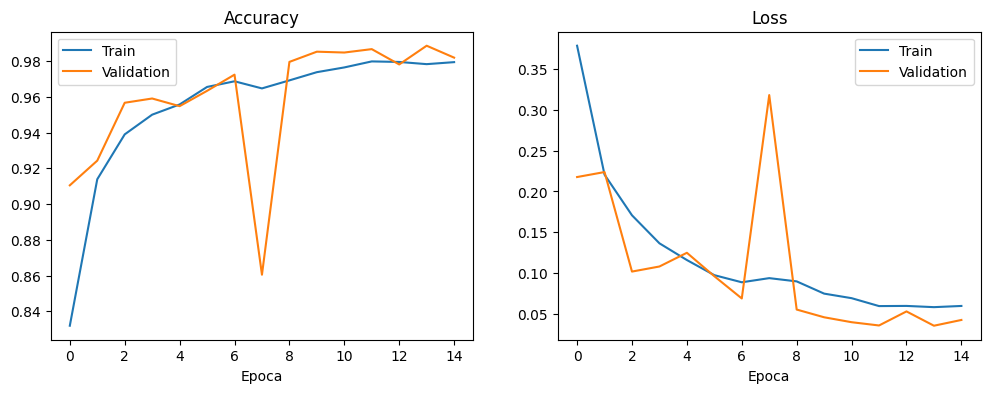

In [12]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoca')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoca')
    ax2.legend()
    plt.show()

plot_history(history)

## 11. Valutazione sul test set (mai visto prima)

**Punto chiave della correzione**: a differenza della versione precedente, qui `test_ds` non è mai stato usato né per l'addestramento né per l'Early Stopping. Le metriche calcolate di seguito sono quindi una stima più onesta delle prestazioni del modello su dati realmente nuovi.

In [13]:
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = np.concatenate([y for _, y in test_ds], axis=0)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


## 12. Confusion matrix

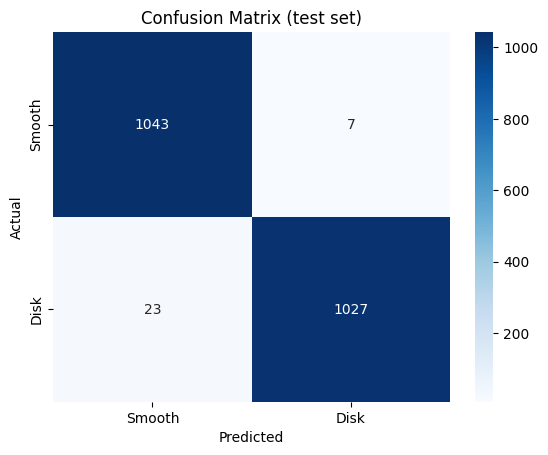

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Smooth', 'Disk'], yticklabels=['Smooth', 'Disk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (test set)')
plt.show()

## 13. Precision, Recall, ROC/AUC

Come visto a lezione: la **Precision** misura quanto è "pura" la classificazione (TP / (TP+FP)), mentre la **Recall** misura quanti oggetti reali sono stati correttamente individuati (TP / (TP+FN)).

**Nota critica.** Se le metriche risultano estremamente alte (vicine al 99%), va ricordato l'avvertimento dato a lezione: *"This can be too good to be true!"*. Nel nostro caso questo è plausibile perché: (a) i criteri di selezione (fraction > 0.9, count > 30) scartano già le galassie ambigue, lasciando solo casi morfologicamente molto netti; (b) il campione è bilanciato artificialmente. Un'accuratezza altissima non implica quindi necessariamente un errore, ma va sempre accompagnata da una verifica indipendente — per questo nelle sezioni successive testiamo il modello con rumore aggiunto e con immagini reali esterne al dataset.

              precision    recall  f1-score   support

      Smooth       0.98      0.99      0.99      1050
        Disk       0.99      0.98      0.99      1050

    accuracy                           0.99      2100
   macro avg       0.99      0.99      0.99      2100
weighted avg       0.99      0.99      0.99      2100



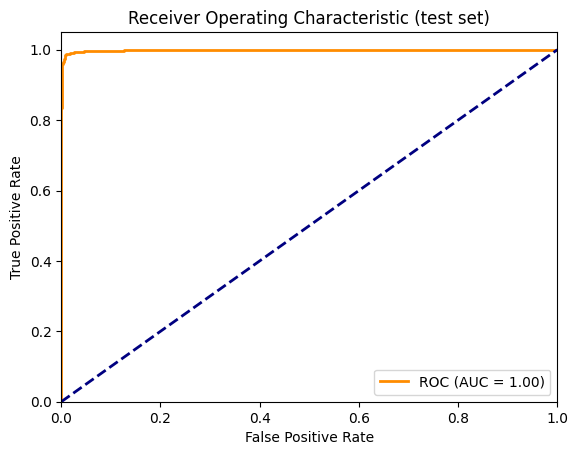

In [15]:
print(classification_report(y_true, y_pred, target_names=['Smooth', 'Disk']))

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (test set)')
plt.legend(loc="lower right")
plt.show()

## 14. Feature maps del primo layer convoluzionale

Visualizziamo l'attivazione del primo blocco convoluzionale per un'immagine del test set, per capire quali pattern la rete utilizza per classificare (struttura della galassia, sfondo, rumore...).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


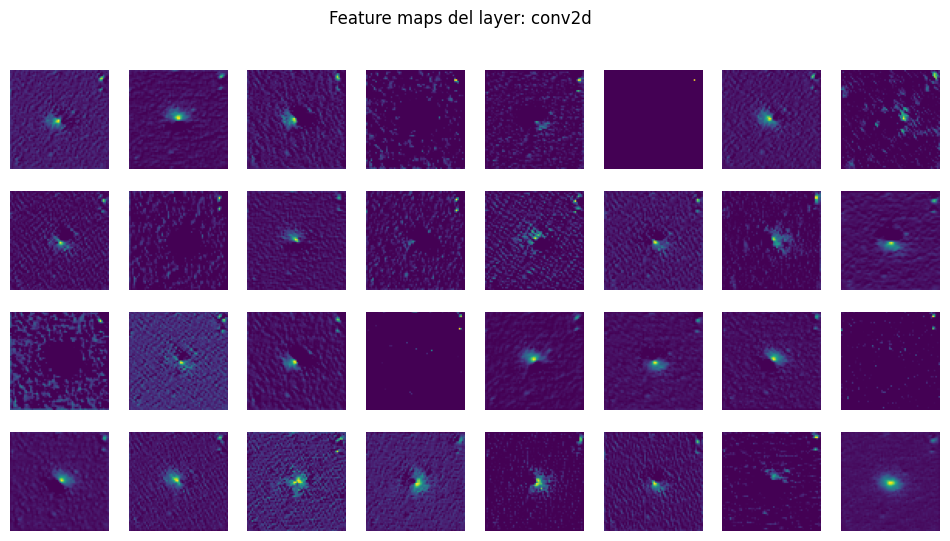

In [16]:
sample_img = X_test[0:1]  # batch di 1

first_conv_layer_name = model.layers[1].name  # primo layer Conv2D
truncated_model = models.Model(inputs=model.inputs,
                                outputs=model.get_layer(first_conv_layer_name).output)

feature_maps = truncated_model.predict(sample_img)  # shape: (1, H, W, 32)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle(f'Feature maps del layer: {first_conv_layer_name}')
plt.show()

## 15. Test di robustezza al rumore (richiesto dal progetto)

Aggiungiamo rumore bianco gaussiano alle immagini del test set, con diverse intensità, e osserviamo come degrada l'accuratezza del modello. Questo permette di capire quanto la classificazione dipenda da dettagli fini dell'immagine piuttosto che dalla struttura globale della galassia.

sigma=0.00  ->  accuracy=0.9857
sigma=0.05  ->  accuracy=0.8881
sigma=0.10  ->  accuracy=0.5152
sigma=0.20  ->  accuracy=0.5019
sigma=0.30  ->  accuracy=0.5005


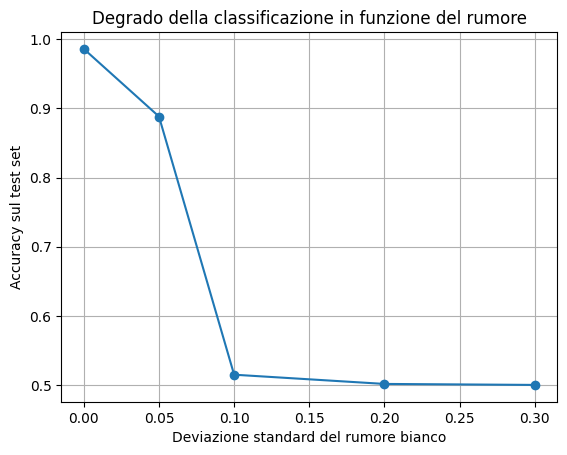

In [17]:
def add_white_noise(images, sigma):
    # Aggiunge rumore gaussiano con deviazione standard sigma e clippa in [0, 1].
    noise = np.random.normal(loc=0.0, scale=sigma, size=images.shape).astype(np.float32)
    noisy = np.clip(images + noise, 0.0, 1.0)
    return noisy

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]
accuracies = []

for sigma in noise_levels:
    X_noisy = add_white_noise(X_test, sigma)
    y_pred_noisy = (model.predict(X_noisy, verbose=0) > 0.5).astype(int).flatten()
    acc = (y_pred_noisy == y_test).mean()
    accuracies.append(acc)
    print(f"sigma={sigma:.2f}  ->  accuracy={acc:.4f}")

plt.figure()
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel('Deviazione standard del rumore bianco')
plt.ylabel('Accuracy sul test set')
plt.title('Degrado della classificazione in funzione del rumore')
plt.grid(True)
plt.show()

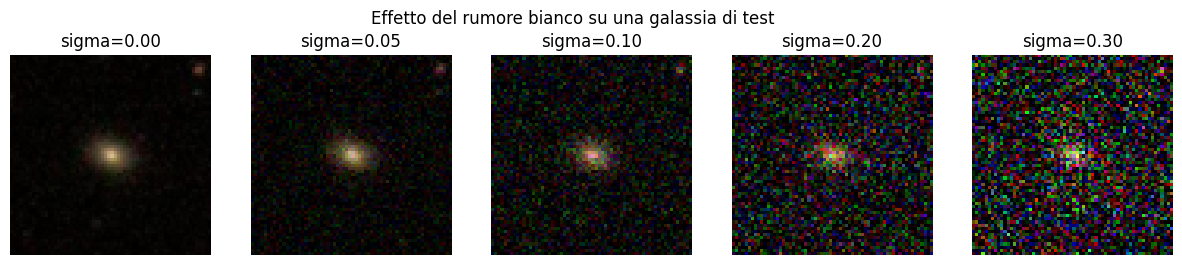

In [18]:
# Esempio visivo: stessa immagine con livelli di rumore crescenti
fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 3))
for ax, sigma in zip(axes, noise_levels):
    noisy_img = add_white_noise(X_test[0:1], sigma)[0]
    ax.imshow(noisy_img)
    ax.set_title(f"sigma={sigma:.2f}")
    ax.axis('off')
plt.suptitle('Effetto del rumore bianco su una galassia di test')
plt.show()

## 16. Test finale: classificazione di un'immagine reale da internet (richiesto dal progetto)

Come indicato nel materiale del corso, il test finale del modello consiste nello scaricare un'immagine di una galassia reale (ad esempio da [legacysurvey.org](https://www.legacysurvey.org/viewer)) e verificare se il modello la classifica correttamente come disco o smooth.

La funzione sotto accetta il percorso locale di un'immagine (es. uno screenshot salvato) e restituisce la predizione del modello. Sostituisci `IMAGE_PATH` con il percorso della tua immagine prima di eseguire la cella.

In [19]:
def classify_external_image(image_path, model, img_size=IMG_SIZE):
    # Classifica un'immagine esterna (es. scaricata da internet) come disco o smooth.
    img = Image.open(image_path).convert("RGB").resize(img_size)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]
    label = "Disk" if prediction > 0.5 else "Smooth"

    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predizione: {label} (score={prediction:.2f})")
    plt.show()

    return label, float(prediction)

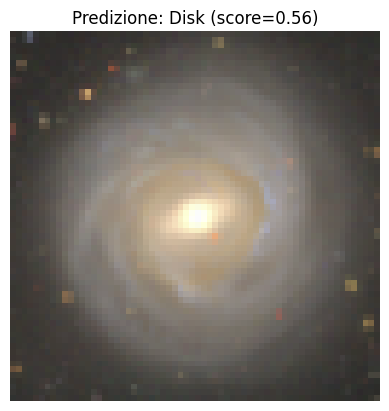

('Disk', 0.5592928528785706)

In [20]:
# Esempio d'uso (sostituire con il percorso reale dell'immagine scaricata):
IMAGE_PATH = "C:\\Users\\kekko\\OneDrive\\Immagini\\Screenshots\\Screenshot 2026-06-28 184049.png"
classify_external_image(IMAGE_PATH, model)

## 17. Conclusioni

- Il modello raggiunge un'accuratezza elevata sul test set **mai visto durante il training**, confermando che le buone prestazioni non sono semplicemente un artefatto del data leakage train/validation/test presente nella versione precedente del notebook.
- Il test di robustezza al rumore mostra (vedi grafico in Sezione 15) quanto rapidamente le prestazioni degradano all'aumentare del rumore: questo aiuta a capire se il modello si basi su feature robuste e strutturali della galassia, o su dettagli fini più sensibili al rumore.
- Il test su immagini reali esterne al dataset (Sezione 16) è il vero banco di prova della capacità di generalizzazione del modello, al di là delle metriche calcolate sul test set interno.
- Resta da ricordare che il campione usato è **bilanciato artificialmente** e selezionato con criteri di accordo molto stringenti (fraction > 0.9): le prestazioni qui misurate sono probabilmente un limite superiore rispetto a quanto si otterrebbe applicando il modello a galassie morfologicamente più ambigue.